In [68]:
import numpy as np
import matplotlib.pyplot as plt

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (COPPER_AVERAGE_REGIONS_TO_IMAGE, 
                                          all_regions_list_class,
                                          models_output_dict)

In [69]:
# COPPER
copper = ResourceModel(resource_group = 'metals', resource = 'copper', 
                       image_mat_available = True, start_year = 1990,
                       scenario= 'SSP2_M_CP', end_year = 2011)

class_1 = ['class_ 1'] 

high = ['class_ 19', 'class_ 23']

china = ['class_ 20']

low = ['class_ 2', 'class_ 11' , 'class_ 12', 'class_ 13', 'class_ 24']

too_low = ['class_ 4', 'class_ 8', 'class_ 22', 'class_ 25']

very_low = ["class_ 3", "class_ 5", "class_ 6", 
              "class_ 7", "class_ 9", "class_ 17", 
              "class_ 18", "class_ 21", "class_ 26"]

# trajectory not to forseen, will be fitted with global regression
spreaded = ['class_ 10', 'class_ 14', 'class_ 15', 'class_ 16']

exclude = spreaded + too_low


# what is in rest will not be fitted because of outliers - will follow global projections       
rest = all_regions_list_class[:-1]
rest = [r for r in rest if r not in (low+class_1+high+very_low+too_low+china)]

# for these models a regression will be made
# all reginos that are not in the high, medium, low will be fitted with the global regression
copper_regions = {'all' : all_regions_list_class[:-1],
                'class_ 1': class_1,
                  'high': high,
                  'china': china,
                  'low': low,
                  'very_low': very_low,
                  'too_low': too_low,
               }


copper.data_grouped_regions(regions_grouping = copper_regions) #list(COPPER_AVERAGE_REGIONS_TO_IMAGE.keys()
copper.sum_IMAGE_drivers_regions(regions_dict=None)
copper.match_MAT_data_to_regions_year(match_external_regions=False)
copper.calculate_historic_other_fraction()

In [70]:
copper.historic_consumption_data

,class_ 1,class_ 2,class_ 3,class_ 4,class_ 5,class_ 6,class_ 7,class_ 8,class_ 9,class_ 10,...,class_ 17,class_ 18,class_ 19,class_ 20,class_ 21,class_ 22,class_ 23,class_ 24,class_ 25,class_ 26
t,,,,,,,,,,,,,,,,,,,,,
1990,474768.040,NaN,159956.419,-711.17300,NaN,380445.4370,NaN,NaN,NaN,NaN,...,7756.300000,119711.855,519103.867,NaN,121365.7460,1738.016,1127134.000,248848.8360,-556.494,-15.965000
1991,499233.048,1823472.936,153811.394,-506.31100,NaN,260456.1670,1600.09000,NaN,NaN,NaN,...,5946.923000,111539.995,467672.772,5.716623e+05,73070.4570,3270.366,1219635.000,260854.8010,-466.314,NaN
1992,477786.203,2074469.534,168333.809,-605.68200,NaN,165827.3180,-8569.41300,NaN,699.435,NaN,...,16798.903000,98943.116,409641.875,1.196946e+06,109921.7890,3702.636,1230969.449,283746.4980,-243.333,NaN
1993,497967.934,2224705.912,145624.155,-2208.26000,NaN,162157.3820,-7271.39600,NaN,NaN,NaN,...,18623.881000,135524.470,394527.543,1.338214e+06,132921.0950,3946.435,1305536.000,290917.8790,-986.279,-422.242000
1994,533887.189,2111402.096,153968.522,-290.52400,NaN,160277.4690,-7097.96900,-39.167,-943.661,NaN,...,16570.939000,134851.519,403204.384,1.510982e+06,77143.3910,1952.189,1225105.063,314514.2120,1437.629,-459.174000
1995,580532.502,2008399.712,143325.486,-1453.83200,NaN,184931.8970,-11554.63900,-2248.312,-814.678,NaN,...,-5415.898000,150477.822,423264.615,2.300185e+06,76022.5590,-1124.043,1277856.000,250149.8160,6.547,-1764.192000
1996,581461.150,2280562.861,146452.206,-3821.78400,NaN,253470.5730,-11993.91200,-7421.112,15344.287,NaN,...,329.610000,178359.530,396021.530,1.941793e+06,88491.3980,-1722.823,1324472.437,295123.9630,20.546,-375.053000
1997,592206.060,2349528.860,226266.577,-3268.78300,NaN,295645.8480,-17208.81100,-4036.216,-1034.553,NaN,...,56600.680000,182308.974,394361.326,2.006058e+06,44474.2380,-1524.383,1365121.234,245548.1370,50.001,-2140.797000
1998,555164.528,2397478.216,452735.359,-2368.87200,NaN,325026.0810,-5447.86600,-4505.615,-1381.856,NaN,...,89955.625000,247255.206,469905.411,2.160947e+06,-4897.1650,-8732.785,1355205.143,-642831.6210,19.142,18485.995000


In [71]:
# deal with single negative numbers in historic other fraction by replacing with np.nan
copper.historic_other_fraction_consumption[copper.historic_other_fraction_consumption < 0] = np.nan
copper.historic_other_fraction_consumption


,class_ 1,class_ 2,class_ 3,class_ 4,class_ 5,class_ 6,class_ 7,class_ 8,class_ 9,class_ 10,...,class_ 17,class_ 18,class_ 19,class_ 20,class_ 21,class_ 22,class_ 23,class_ 24,class_ 25,class_ 26
t,,,,,,,,,,,,,,,,,,,,,
1990,436080.084792,NaN,122354.911347,NaN,NaN,323368.252169,NaN,NaN,NaN,NaN,...,NaN,85374.945168,481551.140090,NaN,72871.627890,NaN,8.226221e+05,195178.340445,NaN,NaN
1991,473120.141790,1.488301e+06,97119.807074,NaN,NaN,203204.641293,NaN,NaN,NaN,NaN,...,NaN,68057.765331,434478.087095,4.876331e+05,44408.159539,NaN,1.009016e+06,231538.178695,NaN,NaN
1992,437646.639568,1.596335e+06,143850.663916,NaN,NaN,108084.876846,NaN,NaN,NaN,NaN,...,NaN,53050.903385,370137.614675,1.094330e+06,68766.724104,NaN,1.060529e+06,247872.773175,NaN,NaN
1993,437790.200309,1.615976e+06,107547.522044,NaN,NaN,93049.904310,NaN,NaN,NaN,NaN,...,NaN,85657.466729,349052.185284,1.220483e+06,66198.204602,NaN,1.100236e+06,253763.118165,NaN,NaN
1994,472824.915524,1.553425e+06,109759.026672,NaN,NaN,112974.201245,NaN,NaN,NaN,NaN,...,NaN,77404.825929,359232.949178,1.475112e+06,21165.314326,NaN,9.817118e+05,272071.315572,NaN,NaN
1995,533835.600961,1.512689e+06,138889.433923,NaN,NaN,111708.241072,NaN,NaN,NaN,NaN,...,NaN,68118.472691,363672.481762,2.207621e+06,NaN,NaN,1.095129e+06,208439.878668,NaN,NaN
1996,549688.760096,1.916213e+06,139696.930478,NaN,NaN,172613.374107,NaN,NaN,9735.203134,NaN,...,NaN,111323.721572,344397.015491,1.746289e+06,21293.888175,NaN,1.142222e+06,253474.190325,NaN,NaN
1997,541680.162652,1.939379e+06,185381.997298,NaN,NaN,247577.993700,NaN,NaN,NaN,NaN,...,NaN,130230.317610,371510.989888,1.972128e+06,NaN,NaN,1.249311e+06,206548.485835,NaN,NaN
1998,508665.672924,1.868551e+06,410869.489803,NaN,NaN,265746.147124,NaN,NaN,NaN,NaN,...,NaN,191064.430755,469199.945228,2.080935e+06,NaN,NaN,1.252015e+06,NaN,NaN,14756.63738


In [72]:
# Fit models 

# Fit models 
best_rmse_models= {
    'all' : 'gompertz model',
    'class_ 1': 'gompertz model',
    'high': 'gompertz model',
    'china': 'gompertz model',
    'low': 'gompertz model',
    'very_low': 'gompertz model',
    'too_low': 'gompertz model'}


bounds = {
    'all' : ([0, 0, 0], [10, 10, 10]),
    'class_ 1': ([0, 2, 2], [10, 10, 10]),
    'high': ([0, 0, 0], [10, 10, 10]),
    'china': ([0, 0, 0], [10, 10, 10]),
    'low': ([0, 0, 0], [10, 10, 10]),
    'very_low': ([0, 0, 0], [10, 10, 10]),
    'too_low': ([0, 0, 0], [10, 10, 10])}


copper.calculate_regressors(copper.historic_other_fraction_consumption)
copper.fit_models(best_rmse_models=best_rmse_models, bounds=bounds)


C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return 

In [73]:
# add regions to regions model match that are not in there yet becaused they are fitted to the global average
for key in COPPER_AVERAGE_REGIONS_TO_IMAGE.keys():
    if key not in copper.region_model_match:
        copper.region_model_match[key] = copper.model_groups.get("all")[6]

# Projections 
copper.project_on_total(all_regions_list_class[:-1])



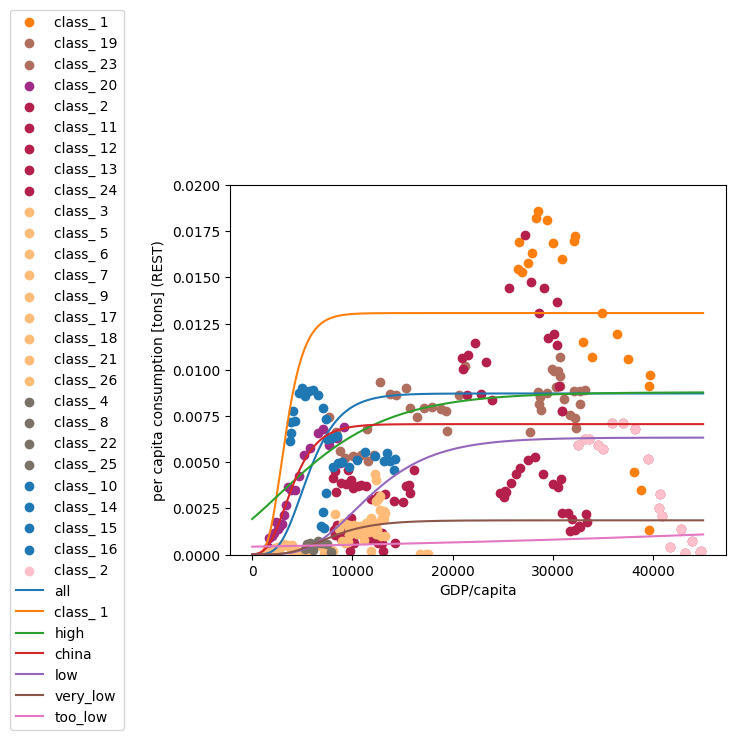

In [76]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis

# Grouping of regions for fitting

color_rest = '#1f77b4'
color_low = "#b41f4c"
color_high = "#070707"
color_china = "#a02c87"
color_class_1 = '#ff7f0e'
color_high = "#af6e5e"
color_class_20 = "#D33778"
color_class_23 = '#2ca02c'
color_very_low = '#ffbb78'
color_too_low = "#7a7167"

color_dict_fits = {
    'rest': color_rest,
    'very_low': color_very_low,
    'too_low': color_too_low,
    'class_ 1': color_class_1,
    'high': color_high,
    'low': color_low,
    'high': color_high,
    'china': color_china,
    'all': "#dceb0c",  # Color for all region
}



fig, ax = plt.subplots()             # Create a figure containing a single Axes.

for region in class_1:
    ax.scatter(copper.gdp_pc[region], 
               copper.cons_capita[region], 
               label = region,
               color = color_class_1)

for region in high:
    ax.scatter(copper.gdp_pc[region], 
               copper.cons_capita[region], 
               label = region,
               color = color_high)

for region in china:
    ax.scatter(copper.gdp_pc[region], 
               copper.cons_capita[region], 
               label = region,
               color = color_china)

for region in low:
    ax.scatter(copper.gdp_pc[region], 
                copper.cons_capita[region], 
                label = region,
                color = color_low)
    
for region in very_low:
    ax.scatter(copper.gdp_pc[region], 
                copper.cons_capita[region], 
                label = region,
                color = color_very_low)

for region in too_low:
    ax.scatter(copper.gdp_pc[region], 
                copper.cons_capita[region], 
                label = region,
                color = color_too_low)

for region in rest:
    ax.scatter(copper.gdp_pc[region], 
                copper.cons_capita[region], 
                label = region,
                color = color_rest)

for region in ["class_ 2"]:
    ax.scatter(copper.gdp_pc[region], 
                copper.cons_capita[region], 
                label = region,
                color = "pink")

for grouping in copper_regions.keys():
    model = copper.model_groups[grouping][models_output_dict[copper.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 45000).reshape(-1, 1)),
            label = grouping)
# set ax limits
ax.set_ylim(0, 0.02)
ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")
ax.legend(loc = 'right', bbox_to_anchor=(-0.2, 0.5))
    

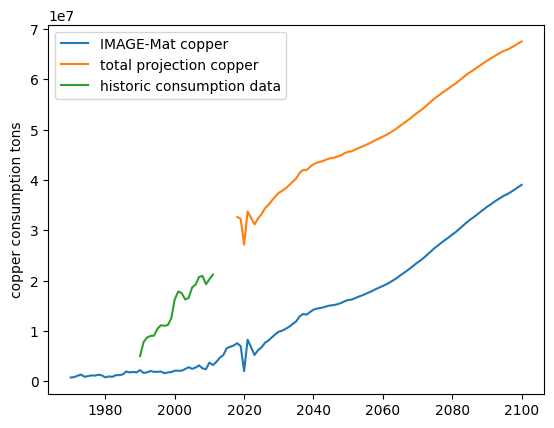

In [75]:
# Plot total copper consumption (all regions)
fig, ax = plt.subplots()             # Create a figure containing a single Axes.


ax.plot(copper.image_mat_data.sum(axis = 1).loc[1970:], label = "IMAGE-Mat copper")
ax.plot((copper.projection_per_region*copper.pop_100.loc[2018:]).sum(axis = 1) + copper.image_mat_data.sum(axis = 1).loc[2018:],
        label = "total projection copper")
ax.plot(copper.historic_consumption_data.sum(axis = 1), label = "historic consumption data")

ax.set_ylabel("copper consumption tons")

ax.legend(loc = 'upper left')

plt.show()